In [1]:
import pandas as pd
import torch
import sys 
sys.path.append("..")
from torch_geometric import seed_everything
import gc
from models.training_utils import load_feature_dict
from data_class import GNNData
import yaml
from model_class import LinkPredictor
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt


sys.path.append("..")
from models.training_utils import NegativeSampler 
data_folder = "/biodata/nyanovsky/datasets/dti/processed/v2/"
nodes = pd.read_csv(f"{data_folder}node_df.csv", index_col="node_id")
edges = pd.read_csv(f"{data_folder}edge_df_dedup.csv")

tensor_df = pd.read_csv(f"{data_folder}dti_tensor_df.csv", index_col=0)


full_dataset = torch.load(f"{data_folder}dti_full_dataset.pt")

In [2]:
nodes.head()

,ChG_deg,ChCh_deg,GG_deg,total_deg,node_type,louvain community (nodetype subgraph)
node_id,,,,,,
C155831,1,4,0,5,chem,141
G5243,41,0,17,58,gene,42
C24762158,9,2,0,11,chem,489
G213,85,0,3,88,gene,2
G506,6,0,3,9,gene,93


In [3]:
edges.head()

,src_id,trgt_id,edge_type,src_node_type,trgt_node_type,src_node_index,trgt_node_index
0,C155831,G5243,chg,chem,gene,0,1
1,C24762158,G213,chg,chem,gene,2,3
2,C24762158,G506,chg,chem,gene,2,4
3,C24762158,G563,chg,chem,gene,2,5
4,C24762158,G13884,chg,chem,gene,2,6


In [4]:
full_data = GNNData(node_path="/biodata/nyanovsky/datasets/dti/processed/v2/node_df.csv",
               edge_path="/biodata/nyanovsky/datasets/dti/processed/v2/edge_df_dedup.csv",
               node_index_col="node_id",
               src_edge_col="src_id",
               dst_edge_col="trgt_id",
               node_type_col="node_type",
               edge_type_col="edge_type",
               src_node_type_col="src_node_type",
               dst_node_type_col="trgt_node_type")

In [5]:
no_chch_data = GNNData(node_path="/biodata/nyanovsky/datasets/dti/processed/v2/node_df.csv",
               edge_path="/biodata/nyanovsky/datasets/dti/processed/v2/edges_no_chch.csv",
               node_index_col="node_id",
               src_edge_col="src_id",
               dst_edge_col="trgt_id",
               node_type_col="node_type",
               edge_type_col="edge_type",
               src_node_type_col="src_node_type",
               dst_node_type_col="trgt_node_type")

no_gg_data = GNNData(node_path="/biodata/nyanovsky/datasets/dti/processed/v2/node_df.csv",
               edge_path="/biodata/nyanovsky/datasets/dti/processed/v2/edges_no_gg.csv",
               node_index_col="node_id",
               src_edge_col="src_id",
               dst_edge_col="trgt_id",
               node_type_col="node_type",
               edge_type_col="edge_type",
               src_node_type_col="src_node_type",
               dst_node_type_col="trgt_node_type")

only_dti_data = GNNData(node_path="/biodata/nyanovsky/datasets/dti/processed/v2/node_df.csv",
               edge_path="/biodata/nyanovsky/datasets/dti/processed/v2/edges_chg.csv",
               node_index_col="node_id",
               src_edge_col="src_id",
               dst_edge_col="trgt_id",
               node_type_col="node_type",
               edge_type_col="edge_type",
               src_node_type_col="src_node_type",
               dst_node_type_col="trgt_node_type")

In [6]:
supervision_edge_type = ("chem", "chg", "gene")
gene_feature_dict = load_feature_dict(data_folder+"prot_features_64.txt", data_folder+"prot_features_ids.txt", 
                                                    tensor_df, "gene")

In [7]:
configs_folder = "/biodata/nyanovsky/datasets/dti/best_models/"
with open(configs_folder+"sage_config.yaml","r") as file:
    sage_config = yaml.safe_load(file)

sage_config["train"].pop("epochs")
sage_config["train"].pop("feature_dim")
sage_config["train"].pop("features")

'go2vec'

In [8]:
datasets = [full_data, no_chch_data, no_gg_data, only_dti_data]
samplers = [NegativeSampler(dataset.data, supervision_edge_type, 
                            dataset.data["chem"].degrees_by_edge_type[supervision_edge_type],
                            dataset.data["gene"].degrees_by_edge_type[supervision_edge_type])
                            for dataset in datasets]

In [10]:
'''
results_df = pd.DataFrame(index=["with_features", "without_features"], columns=["full", "no_chch", "no_gg", "only_dti"])
for feat in results_df.index:
    for name,net, sampler in zip(results_df.columns, datasets, samplers):
        aucs = []

        if feat == "with_features":
            net.initialize_features(64, gene_feature_dict, inplace=True)
        else:
            net.initialize_features(64, feature_dict=None, inplace=True)
            
        for i in range(10):
            seed_everything(i)
            train, val, test = net.split_data(task="link_prediction", supervision_edge_type=supervision_edge_type, 
                                 negative_sampler=sampler,
                                 disjoint_train_ratio=0.2, 
                                 num_val=0.1,
                                 num_test=0.1)
            splits = {"train":train, "val":val, "test":test}
            model.train(splits, sampler, supervision_edge_type, 500)
            auc = model.evaluate(test)['roc_auc']
            aucs.append(auc)

            model.reset()
            del model 
            del splits 
            gc.collect()
            torch.cuda.empty_cache()

            model = LinkPredictor(conv_name="SAGE",
                      gral_params=sage_config["gral"],
                      conv_params=sage_config["conv"],
                      optimizer_params=sage_config["train"])
            
        results_df.loc[feat,name] = aucs
        print(f"{name} {feat} mean auc: {np.mean(aucs)}")'''

'\nresults_df = pd.DataFrame(index=["with_features", "without_features"], columns=["full", "no_chch", "no_gg", "only_dti"])\nfor feat in results_df.index:\n    for name,net, sampler in zip(results_df.columns, datasets, samplers):\n        aucs = []\n\n        if feat == "with_features":\n            net.initialize_features(64, gene_feature_dict, inplace=True)\n        else:\n            net.initialize_features(64, feature_dict=None, inplace=True)\n            \n        for i in range(10):\n            seed_everything(i)\n            train, val, test = net.split_data(task="link_prediction", supervision_edge_type=supervision_edge_type, \n                                 negative_sampler=sampler,\n                                 disjoint_train_ratio=0.2, \n                                 num_val=0.1,\n                                 num_test=0.1)\n            splits = {"train":train, "val":val, "test":test}\n            model.train(splits, sampler, supervision_edge_type, 500)\n        

In [9]:
seed_everything(42)
only_dti_data.initialize_features(64, feature_dict=None, inplace=True)

In [10]:
sage_config

{'conv': {'aggr': 'max'},
 'gral': {'L2_norm': False,
  'batch_norm': False,
  'dropout': 0.0,
  'hidden_channels': 32,
  'layer_connectivity': 'False',
  'macro_aggregation': 'sum',
  'msg_passing_layers': 4,
  'normalize_output': False,
  'post_process_layers': 0,
  'pre_process_layers': 0},
 'train': {'delta': 0.1, 'lr': 0.01, 'patience': 10, 'weight_decay': 0.001}}

In [11]:
def get_seed_results(seed, net, sampler, deterministic_sampling=False):
    model = LinkPredictor(conv_name="SAGE",
                      gral_params=sage_config["gral"],
                      conv_params=sage_config["conv"],
                      optimizer_params=sage_config["train"])
    seed_everything(seed)
    train, val, test = net.split_data(task="link_prediction", supervision_edge_type=supervision_edge_type, 
                                 negative_sampler=sampler,
                                 disjoint_train_ratio=0.2, 
                                 num_val=0.1,
                                 num_test=0.1)
    splits = {"train":train, "val":val, "test":test}
    model.train(splits, sampler, supervision_edge_type, 500, deterministic_sampling)

    return model, splits
    

In [16]:
for seed in range(10):
    model, splits = get_seed_results(seed, only_dti_data, samplers[-1], True)
    print(f"seed {seed} auc = {model.evaluate(splits['test'])['roc_auc']}")
    model.reset()
    del model
    del splits 
    gc.collect()
    with torch.no_grad():
        torch.cuda.empty_cache()    

seed 0 auc = 0.912
seed 1 auc = 0.914
seed 2 auc = 0.913
seed 3 auc = 0.914
seed 4 auc = 0.912
seed 5 auc = 0.919
seed 6 auc = 0.918
seed 7 auc = 0.916
seed 8 auc = 0.919
seed 9 auc = 0.911


In [17]:
for seed in range(10):
    for i in range(10):
        model, splits = get_seed_results(seed, only_dti_data, samplers[-1])
        print(f"seed {seed}, it {i} auc = {model.evaluate(splits['test'])['roc_auc']}")
        model.reset()
        del model
        del splits 
        gc.collect()
        with torch.no_grad():
            torch.cuda.empty_cache()    

seed 0, it 0 auc = 0.918
seed 0, it 1 auc = 0.917
seed 0, it 2 auc = 0.915
seed 0, it 3 auc = 0.912
seed 0, it 4 auc = 0.919
seed 0, it 5 auc = 0.915
seed 0, it 6 auc = 0.914
seed 0, it 7 auc = 0.914
seed 0, it 8 auc = 0.915
seed 0, it 9 auc = 0.918
seed 1, it 0 auc = 0.917
seed 1, it 1 auc = 0.914
seed 1, it 2 auc = 0.913
seed 1, it 3 auc = 0.915
seed 1, it 4 auc = 0.914
seed 1, it 5 auc = 0.913
seed 1, it 6 auc = 0.916
seed 1, it 7 auc = 0.916
seed 1, it 8 auc = 0.919
seed 1, it 9 auc = 0.918
seed 2, it 0 auc = 0.911
seed 2, it 1 auc = 0.911
seed 2, it 2 auc = 0.914
seed 2, it 3 auc = 0.911
seed 2, it 4 auc = 0.912
seed 2, it 5 auc = 0.904
seed 2, it 6 auc = 0.909
seed 2, it 7 auc = 0.904
seed 2, it 8 auc = 0.908
seed 2, it 9 auc = 0.91
seed 3, it 0 auc = 0.912
seed 3, it 1 auc = 0.915
seed 3, it 2 auc = 0.917
seed 3, it 3 auc = 0.913
seed 3, it 4 auc = 0.916
seed 3, it 5 auc = 0.916
seed 3, it 6 auc = 0.914
seed 3, it 7 auc = 0.916
seed 3, it 8 auc = 0.915
seed 3, it 9 auc = 0.916
s

In [13]:
sage_config["gral"]["msg_passing_layers"] = 3


model_0_k3, split_0_k3 = get_seed_results(0, only_dti_data, samplers[-1])
model_1_k3, split_1_k3 = get_seed_results(1, only_dti_data, samplers[-1])

print(f'model 0, k=3, split 0: {model_0_k3.evaluate(split_0_k3["test"])}')
print(f'model 1, k=3, split 1: {model_1_k3.evaluate(split_1_k3["test"])}')

print(f'model 0, k=3, split 1: {model_0_k3.evaluate(split_1_k3["test"])}')
print(f'model 1, k=3, split 0: {model_1_k3.evaluate(split_0_k3["test"])}')

sage_config["gral"]["msg_passing_layers"] = 4

model_0_k4, split_0_k4 = get_seed_results(0, only_dti_data, samplers[-1])
model_1_k4, split_1_k4 = get_seed_results(1, only_dti_data, samplers[-1])

print(f'model 0, k=4, split 0: {model_0_k4.evaluate(split_0_k4["test"])}')
print(f'model 1, k=4, split 1: {model_1_k4.evaluate(split_1_k4["test"])}')

print(f'model 0, k=4, split 1: {model_0_k4.evaluate(split_1_k4["test"])}')
print(f'model 1, k=4, split 0: {model_1_k4.evaluate(split_0_k4["test"])}')

model 0, k=3, split 0: {'loss': 0.3648357689380646, 'roc_auc': 0.914}
model 1, k=3, split 1: {'loss': 0.3628523647785187, 'roc_auc': 0.917}
model 0, k=3, split 1: {'loss': 0.365731418132782, 'roc_auc': 0.913}
model 1, k=3, split 0: {'loss': 0.3647057116031647, 'roc_auc': 0.916}
model 0, k=4, split 0: {'loss': 0.3905801475048065, 'roc_auc': 0.903}
model 1, k=4, split 1: {'loss': 0.6857067346572876, 'roc_auc': 0.569}
model 0, k=4, split 1: {'loss': 0.387067049741745, 'roc_auc': 0.905}
model 1, k=4, split 0: {'loss': 0.6855247616767883, 'roc_auc': 0.57}


In [14]:
def get_layers_embeddings(model, data):
    model.eval()
    embs = [data.x_dict]
    for layer_name in model.encoder._modules.keys():
        layer = model.encoder._modules[layer_name]
        if layer_name == "message_passing":
            for conv_layer in layer.layers:
                embs.append(conv_layer(embs[-1], data.edge_index_dict))
        else:
            embs.append(layer(embs[-1]))
    return embs

In [15]:
embs_0_k3 = get_layers_embeddings(model_0_k3._model, split_0_k3["train"])
embs_0_k4 = get_layers_embeddings(model_0_k4._model, split_0_k4["train"])

embs_1_k3 = get_layers_embeddings(model_1_k3._model, split_1_k3["train"])
embs_1_k4 = get_layers_embeddings(model_1_k4._model, split_1_k4["train"])

In [16]:
def cos_dist_matrix(embs1, embs2):
    normalized_embs_1 = embs1/embs1.norm(dim=1, keepdim=True)
    normalized_embs_2 = embs2/embs2.norm(dim=1, keepdim=True)
    cos_dist = 1- (normalized_embs_1 @ normalized_embs_2.t())
    return cos_dist

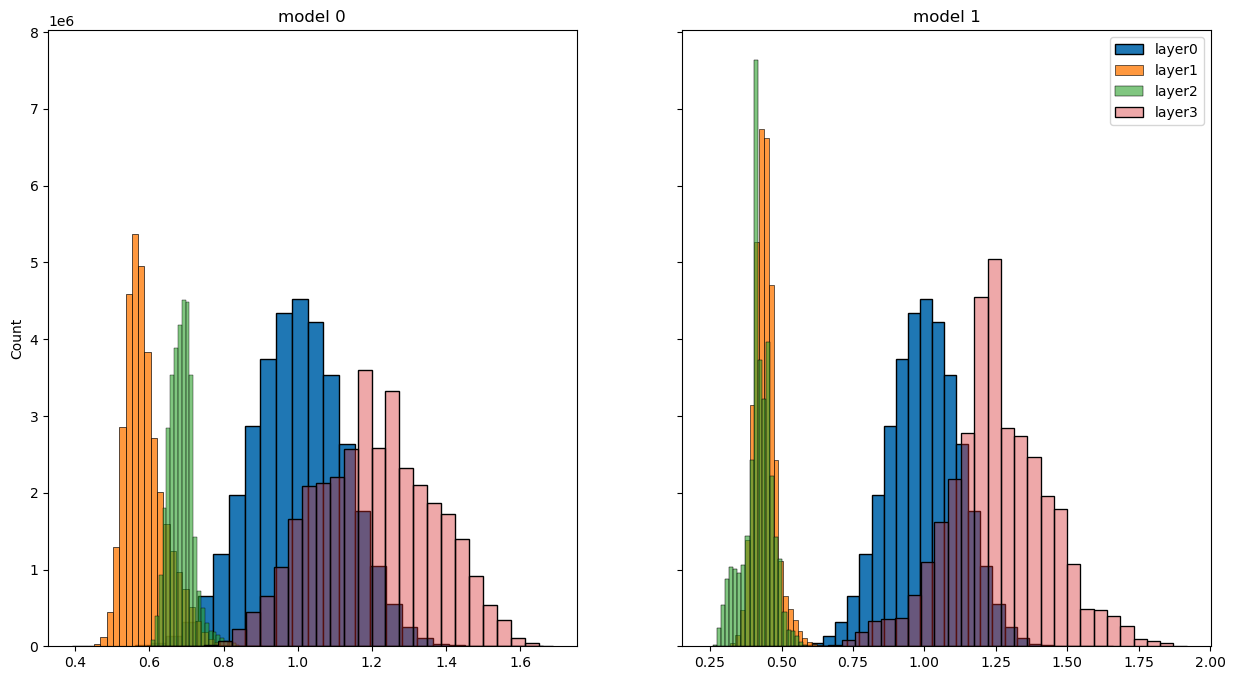

In [57]:
import seaborn as sns 
import matplotlib.pyplot as plt 

fig, axes = plt.subplots(1,2,sharey=True, figsize=(15,8))

for i in range(4):
    cos_dists_0_k3_i = cos_dist_matrix(embs_0_k3[i]["chem"], embs_0_k3[i]["gene"]).detach().cpu()
    cos_dists_1_k3_i = cos_dist_matrix(embs_1_k3[i]["chem"], embs_1_k3[i]["gene"]).detach().cpu() 

    sns.histplot(cos_dists_0_k3_i.view(-1), label=f"layer{i}", ax=axes[0], alpha=1-i*0.2, bins=30)
    sns.histplot(cos_dists_1_k3_i.view(-1), label=f"layer{i}", ax=axes[1], alpha=1-i*0.2, bins=30)

axes[0].set_title("model 0")
axes[1].set_title("model 1")
plt.legend()

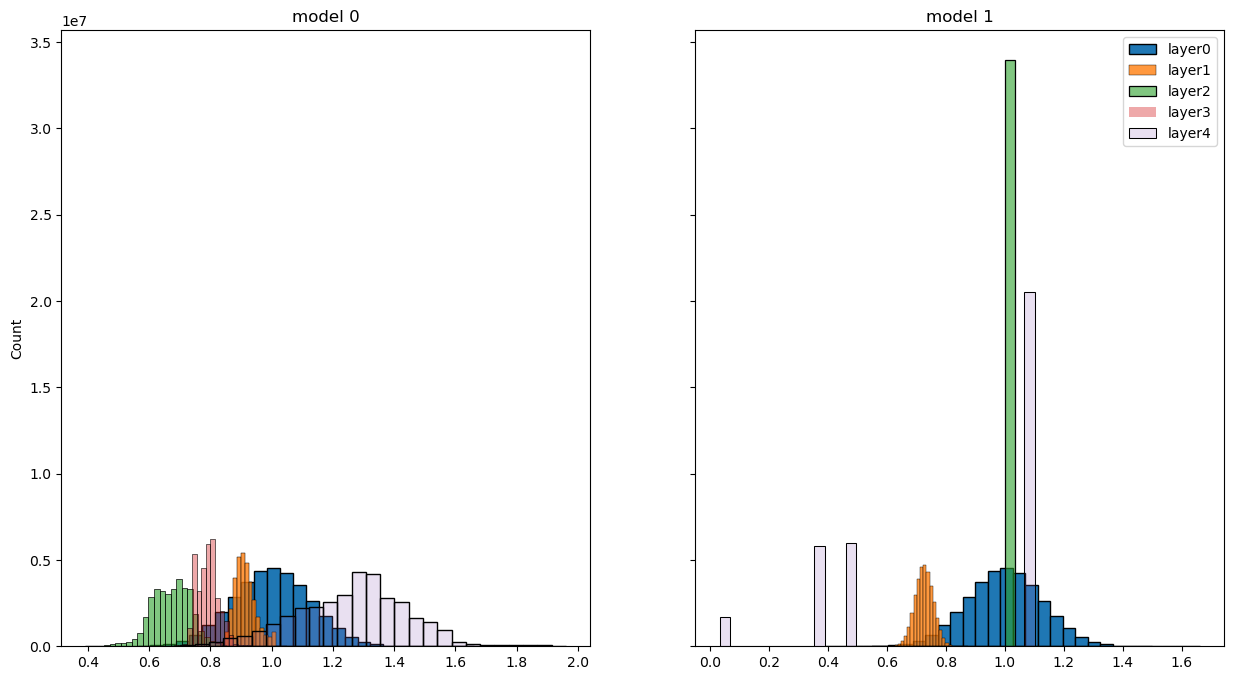

In [58]:
fig, axes = plt.subplots(1,2,sharey=True, figsize=(15,8))

for i in range(5):
    cos_dists_0_k4_i = cos_dist_matrix(embs_0_k4[i]["chem"], embs_0_k4[i]["gene"]).detach().cpu()
    cos_dists_1_k4_i = cos_dist_matrix(embs_1_k4[i]["chem"], embs_1_k4[i]["gene"]).detach().cpu() 

    sns.histplot(cos_dists_0_k4_i.view(-1), label=f"layer{i}", ax=axes[0], alpha=1-i*0.2, bins=30)
    sns.histplot(cos_dists_1_k4_i.view(-1), label=f"layer{i}", ax=axes[1], alpha=1-i*0.2, bins=30)

axes[0].set_title("model 0")
axes[1].set_title("model 1")
plt.legend()

In [ ]:
# TODO: agarrar aristas de supervision en training y checkear grado medio de los nodos 
# (puede ser por separado para cada punta o el promdio de las puntas) a 1, 2, 3 y 4 pasos
# uno esperaria que para el split malo la distribucion de grados medios este corrida mas a la derecha en la capa 2 o 3

In [17]:
def get_split_induced_degrees(splits):
    src, _, dst = supervision_edge_type 
    induced_degs = {src:{}, dst:{}}
    n_src = splits["train"][src].num_nodes
    n_dst = splits["train"][dst].num_nodes
    for split, data in splits.items():
        split_edge_index = data[supervision_edge_type].edge_index

        induced_degs[src][split] = {}
        for i in range(n_src):
            deg_split_i = len(split_edge_index[1, split_edge_index[0]==i])
            induced_degs[src][split][i] = deg_split_i
        
        induced_degs[dst][split] = {}
        for j in range(n_dst):
            deg_split_j = len(split_edge_index[0, split_edge_index[1]==j])
            induced_degs[dst][split][j] = deg_split_j
        
    return induced_degs 


In [28]:
induced_split_degs_0 = get_split_induced_degrees(split_0_k4)
induced_split_degs_1 = get_split_induced_degrees(split_1_k4)

In [29]:
from torch_geometric.utils import k_hop_subgraph

In [86]:
def calculate_shell_till_k(node_idx, nodetype,k, data):

    shell = []
    src, _, dst = supervision_edge_type
    if nodetype == dst:
        src, dst = 1,0 
    else: 
        src,dst = 0,1
    neighs = data[supervision_edge_type].edge_index[dst, data[supervision_edge_type].edge_index[src]==node_idx]
    shell.append(neighs)

    for i in range(1,k):
        src,dst = dst,src 
        neighs_i = torch.cat([data[supervision_edge_type].edge_index[dst, data[supervision_edge_type].edge_index[src]==idx.item()] for idx in shell[-1]]).unique()
        shell.append(neighs_i)

    return shell


    
         

In [22]:
def get_induced_edge_degrees(split):
    src_type, _, dst_type = supervision_edge_type
    deg_data = {} 
    induced_node_degs = get_split_induced_degrees(split)
    for split, data in split.items():
        data.to("cpu")
        sup_edge_index = data.edge_label_index_dict[supervision_edge_type]
        pos_idxs = data.edge_label_dict[supervision_edge_type]==1
        neg_idxs = data.edge_label_dict[supervision_edge_type]==0
        src_degs = [induced_node_degs[src_type][split][idx] for idx in sup_edge_index[0].numpy()]
        dst_degs = [induced_node_degs[dst_type][split][idx] for idx in sup_edge_index[1].numpy()]

        degs = torch.tensor([src_degs, dst_degs])
        deg_data[split] = {"pos":degs[:,pos_idxs].sum(dim=0), "neg":degs[:,neg_idxs].sum(dim=0)}
    return deg_data

In [23]:
induced_edge_degs_0 = get_induced_edge_degrees(split_0)
induced_edge_degs_1 = get_induced_edge_degrees(split_1)

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

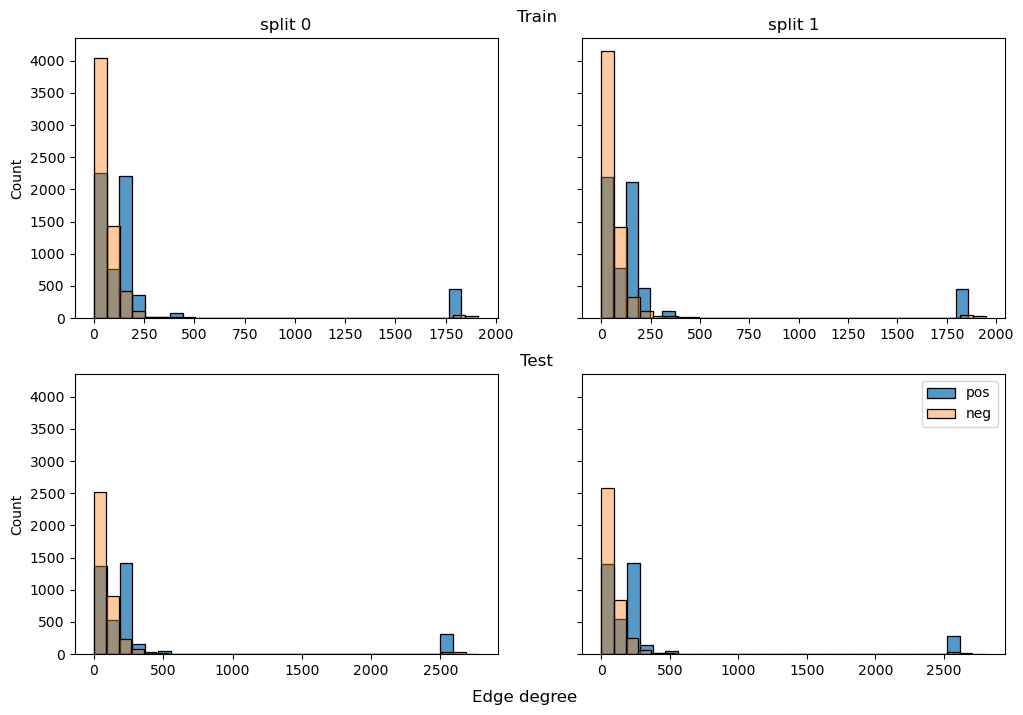

In [54]:
fig, axes = plt.subplots(2,2, sharey=True, figsize=(12,8))
sns.histplot(induced_edge_degs_0["train"]["pos"], ax = axes[0,0], bins=30, label="pos")
sns.histplot(induced_edge_degs_0["train"]["neg"], ax=axes[0,0],bins=30, label="neg", alpha=0.4)
axes[0,0].set_title("split 0")
sns.histplot(induced_edge_degs_1["train"]["pos"], ax = axes[0,1], bins=30, label="pos")
sns.histplot(induced_edge_degs_1["train"]["neg"], ax=axes[0,1],bins=30, label="neg",alpha=0.4)
axes[0,1].set_title("split 1")
fig.text(0.5, 0.05, "Edge degree", ha="center", fontsize=12)
fig.text(0.51, 0.9, "Train", ha="center", fontsize=12)

sns.histplot(induced_edge_degs_0["test"]["pos"], ax = axes[1,0], bins=30, label="pos")
sns.histplot(induced_edge_degs_0["test"]["neg"], ax=axes[1,0],bins=30, label="neg", alpha=0.4)

sns.histplot(induced_edge_degs_1["test"]["pos"], ax = axes[1,1], bins=30, label="pos")
sns.histplot(induced_edge_degs_1["test"]["neg"], ax=axes[1,1],bins=30, label="neg",alpha=0.4)

fig.text(0.51, 0.47, "Test", ha="center", fontsize=12)



plt.legend()

In [62]:
adj_train_0 = split_0["train"][supervision_edge_type].adj_t # genes x drogas

In [88]:
adj_train_0

SparseTensor(row=tensor([   0,    0,    0,  ..., 5799, 5801, 5804]),
             col=tensor([ 809,  894,  900,  ..., 1967, 2295, 2156]),
             size=(5805, 5854), nnz=24571, density=0.07%)

In [92]:
from torch_sparse import SparseTensor

SparseTensor.from_dense(torch.diag_embed(adj_train_0.sum(dim=1))) @ adj_train_0

SparseTensor(row=tensor([   0,    0,    0,  ..., 5799, 5801, 5804]),
             col=tensor([ 809,  894,  900,  ..., 1967, 2295, 2156]),
             val=tensor([30., 30., 30.,  ...,  1.,  1.,  1.]),
             size=(5805, 5854), nnz=24571, density=0.07%)

In [64]:
adj_train_1 = split_1["train"][supervision_edge_type].adj_t

In [110]:
adj_train_0.sum(dim=1)

tensor([30., 59.,  4.,  ...,  0.,  0.,  1.])

In [111]:
def get_deg_matrices(split):
    src, dst = "gene", "chem"
    deg_matrices = {}
    for split, data in split.items():
        adj_split = data[supervision_edge_type].adj_t 

        deg_src = adj_split.sum(dim=1)
        deg_dst = adj_split.sum(dim=0)

        deg_src = torch.diag(deg_src)
        deg_dst = torch.diag(deg_dst)

        deg_matrices[split] = {src: deg_src, dst: deg_dst}
    return deg_matrices


def get_simple_three_hop_matrices(split):
    src, dst = "gene", "chem"
    deg_matrices = get_deg_matrices(split)
    three_hop_matrices = {}
    for split, data in split.items():
        adj_split = data[supervision_edge_type].adj_t.to_dense()

        deg_src = deg_matrices[split][src]
        deg_dst = deg_matrices[split][dst]

        three_hop_mat = adj_split@adj_split.t()@adj_split - deg_src@adj_split - adj_split@deg_dst + adj_split
        three_hop_matrices[split] = three_hop_mat
    return three_hop_matrices        

In [112]:
three_hop_mat_0 = get_simple_three_hop_matrices(split_0)
three_hop_mat_1 = get_simple_three_hop_matrices(split_1)

In [113]:
three_hop_mat_0["train"]

tensor([[  0.,   0.,  10.,  ..., 485., 480.,  20.],
        [  0.,   1.,   3.,  ...,   8.,   9.,   1.],
        [  0.,   0.,   0.,  ...,   0.,   0.,   0.],
        ...,
        [  0.,   0.,   0.,  ...,   0.,   0.,   0.],
        [  0.,   0.,   0.,  ...,   0.,   0.,   0.],
        [  0.,   0.,   1.,  ...,   0.,   0.,   0.]])

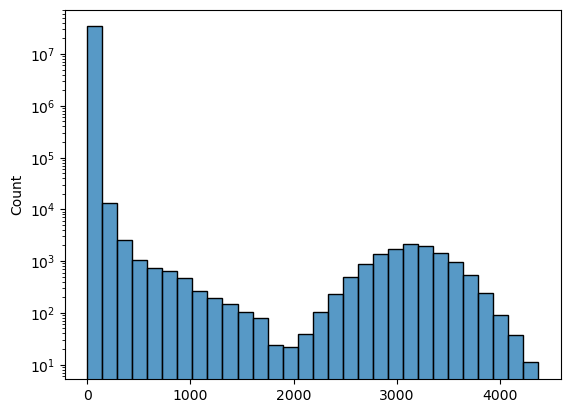

In [115]:
sns.histplot(three_hop_mat_0["train"].view(-1), bins=30)
plt.yscale("log")

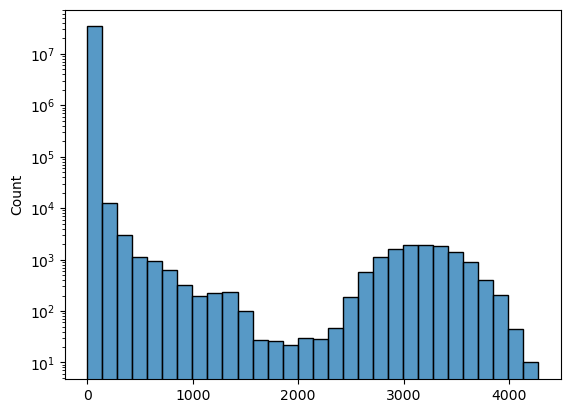

In [116]:
sns.histplot(three_hop_mat_1["train"].view(-1), bins=30)
plt.yscale("log")